# Stage 1 — Faithfulness RD Analysis

This notebook analyses the Risk Difference (RD) results from the faithfulness pipeline.

**Condition contrast**: with-context vs no-context responses on SQuAD questions.

- **Positive RD** → expert more active when the model has context (faithful behaviour)
- **Negative RD** → expert more active when the model lacks context (confabulation behaviour)

Two RD variants are analysed:
- **Frequency-based RD**: based on how often each expert is selected (top-6)
- **Logit-based RD**: based on the mean raw gate logit score per expert

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats
import pandas as pd

sys.path.insert(0, os.path.join('..', 'src'))
from rd_utils import load_rd

import seaborn as sns
sns.set_theme(style='whitegrid', font='serif')
plt.rcParams.update({
    'font.family': 'serif', 'font.size': 12,
    'axes.titlesize': 14, 'axes.labelsize': 12, 'figure.dpi': 150
})

RD_FREQ_PATH  = '/scratch/sc23jc3/results/rd_faithfulness.json'
RD_LOGIT_PATH = '/scratch/sc23jc3/results/rd_faithfulness_logits.json'
OUT_DIR = 'figures'
os.makedirs(OUT_DIR, exist_ok=True)

In [2]:
rd_freq  = load_rd(RD_FREQ_PATH)
rd_logit = load_rd(RD_LOGIT_PATH)

layers_sorted = sorted(rd_freq.keys(), key=lambda x: int(x.split('.')[2]))
layer_indices = [int(l.split('.')[2]) for l in layers_sorted]
print(f'Layers: {len(layers_sorted)},  Experts per layer: {len(next(iter(rd_freq.values())))}')

Layers: 26,  Experts per layer: 64


## 1. RD Distribution — Is the 90th Percentile Threshold Principled?

Each panel shows the distribution of all 1,664 RD values. Dashed/dotted lines mark the 90th and 95th percentiles defining the butterfly scatter threshold. The statistics box shows the fraction clustering near zero (background noise) vs the discriminative tail.

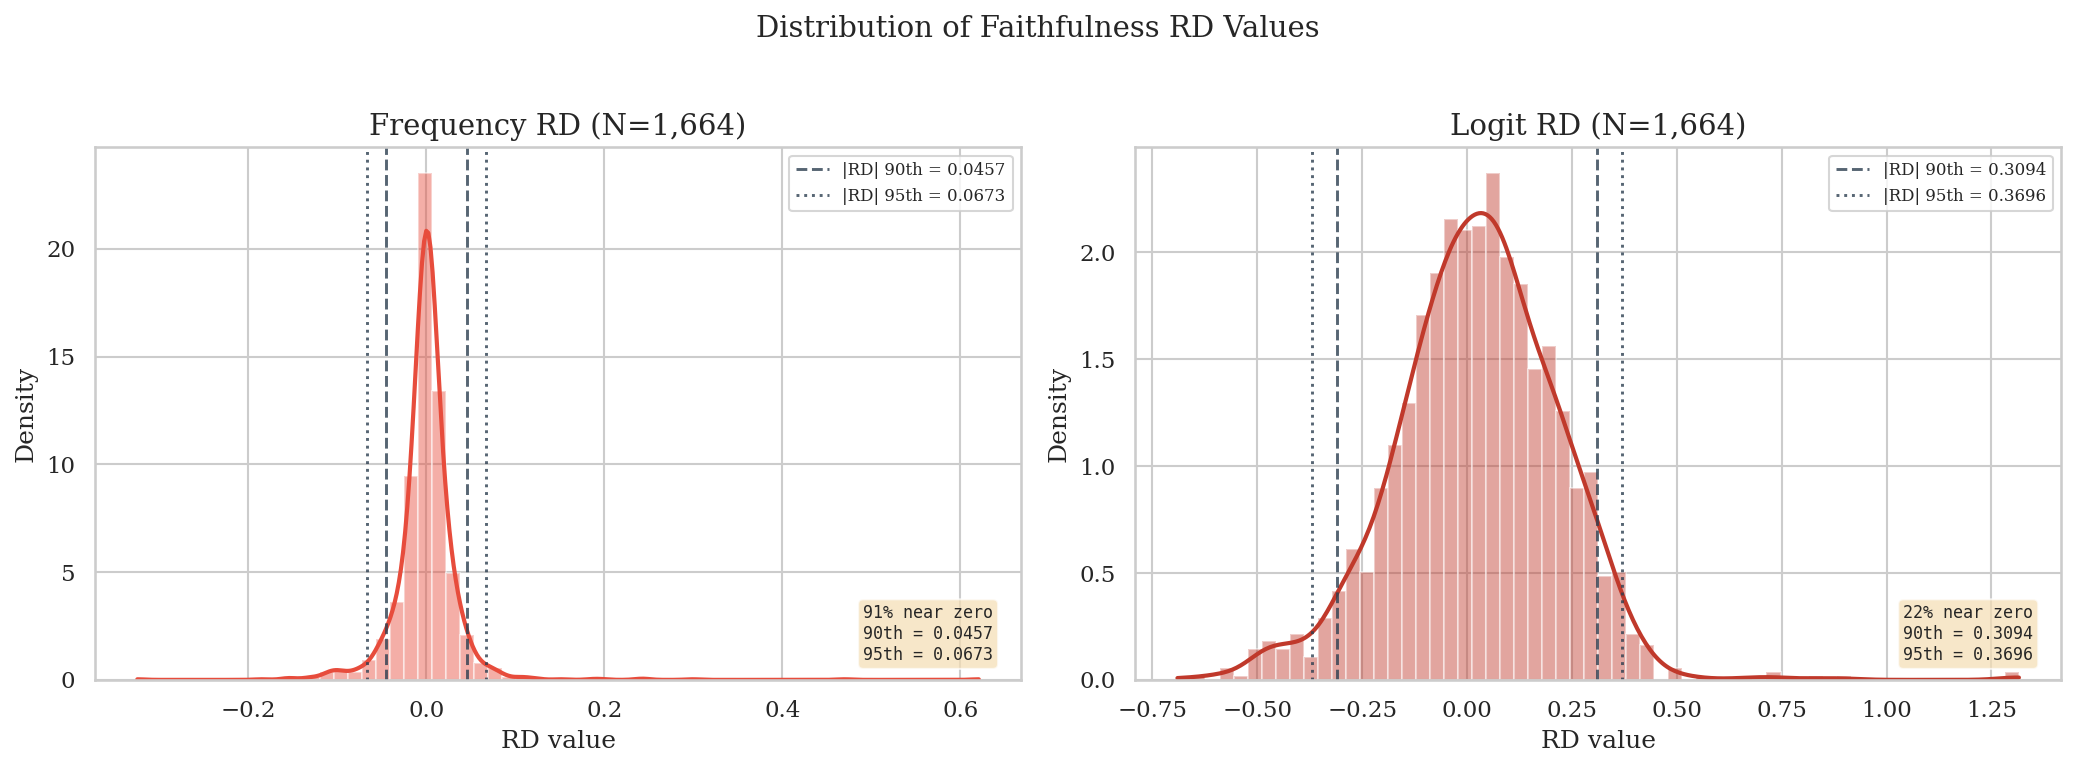

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Flatten all RD values across all (layer, expert) pairs
freq_flat  = np.concatenate([rd_freq[l] for l in layers_sorted])
logit_flat = np.concatenate([rd_logit[l] for l in layers_sorted])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, vals, label, color in zip(
    axes,
    [freq_flat, logit_flat],
    ['Frequency RD', 'Logit RD'],
    ['#e74c3c', '#c0392b']
 ):
    ax.hist(vals, bins=60, alpha=0.45, color=color, density=True)
    kde_x = np.linspace(vals.min(), vals.max(), 400)
    kde = stats.gaussian_kde(vals)
    ax.plot(kde_x, kde(kde_x), color=color, linewidth=2)

    near_zero = np.mean(np.abs(vals) < 0.05) * 100
    p90 = np.percentile(np.abs(vals), 90)
    p95 = np.percentile(np.abs(vals), 95)

    for q, ls, lbl in [(90, '--', '90th'), (95, ':', '95th')]:
        thresh = np.percentile(np.abs(vals), q)
        ax.axvline(thresh, color='#2c3e50', linestyle=ls, alpha=0.8, linewidth=1.4,
                   label=f'|RD| {lbl} = {thresh:.4f}')
        ax.axvline(-thresh, color='#2c3e50', linestyle=ls, alpha=0.8, linewidth=1.4)

    stats_text = f'{near_zero:.0f}% near zero\n90th = {p90:.4f}\n95th = {p95:.4f}'
    ax.text(0.97, 0.03, stats_text, transform=ax.transAxes,
            fontsize=8, ha='right', va='bottom', family='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

    ax.set_xlabel('RD value')
    ax.set_ylabel('Density')
    ax.set_title(f'{label} (N={len(vals):,})')
    ax.legend(fontsize=8)

plt.suptitle('Distribution of Faithfulness RD Values', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## 2. Top Experts by |RD| — Frequency and Logit (Side by Side)

In [4]:
import pandas as pd
from IPython.display import HTML, display

def top_experts_table(rd_by_layer, top_n=20):
    rows = []
    for layer, rd in rd_by_layer.items():
        layer_idx = int(layer.split('.')[2])
        for expert_idx, val in enumerate(rd):
            rows.append((abs(val), val, layer_idx, expert_idx))
    rows.sort(reverse=True)
    df = pd.DataFrame([
        {'Rank': rank, 'Layer': f'L{layer}', 'Expert': f'e{expert}',
         'RD': round(val, 6), 'Direction': 'with-context' if val > 0 else 'no-context'}
        for rank, (_, val, layer, expert) in enumerate(rows[:top_n], 1)
    ]).set_index('Rank')

    styler = (
        df.style
        .set_properties(subset=['Layer', 'Expert', 'Direction'], **{'color': '#000000', 'background-color': '#ffffff'})
        .set_properties(subset=['RD'], **{'color': '#000000'})
        .background_gradient(subset=['RD'], cmap='RdBu_r', vmin=-0.7, vmax=0.7)
        .format({'RD': '{:+.6f}'})
    )
    return styler

freq_html = top_experts_table(rd_freq).to_html()
logit_html = top_experts_table(rd_logit).to_html()

display(HTML(f'''
<style>
  .rd-grid {{ display:flex; gap:16px; align-items:flex-start; }}

  .rd-col {{
    flex:1 1 0;
    min-width:0;
    border:1px solid #ddd;
    border-radius:8px;
    padding:10px;
    background:#ffffff;
    color:#000000;
  }}

  .rd-wrap {{ overflow-x:auto; }}

  .rd-col h4 {{
    margin:0 0 8px 0;
    font-size:16px;
    color:#000000;
    font-weight:600;
  }}

  .rd-col table {{
    width:100%;
    table-layout:auto;
    font-size:14px;
    line-height:1.35;
    color:#000000;
    font-family:"Segoe UI", Arial, sans-serif;
  }}

  .rd-col th {{
    color:#000000;
    font-weight:700;
  }}

  .rd-col td {{
    color:#000000;
    font-weight:500;
    letter-spacing:0.2px;
  }}

  .rd-col th, .rd-col td {{
    white-space:nowrap;
    padding:6px 8px;
    text-align:left;
  }}

  .rd-col table,
  .rd-col th,
  .rd-col td {{
    color:#000000 !important;
    opacity:1 !important;
  }}
</style>
<div class="rd-grid">
  <div class="rd-col">
    <h4>Frequency RD</h4>
    <div class="rd-wrap">{freq_html}</div>
  </div>
  <div class="rd-col">
    <h4>Logit RD</h4>
    <div class="rd-wrap">{logit_html}</div>
  </div>
</div>
'''))

,Layer,Expert,RD,Direction
Rank,,,,
1,L11,e53,+0.620646,with-context
2,L12,e45,+0.469799,with-context
3,L10,e19,-0.324864,no-context
4,L13,e30,+0.299297,with-context
5,L6,e20,+0.242729,with-context
6,L11,e2,+0.242410,with-context
7,L7,e5,+0.195909,with-context
8,L22,e8,+0.186961,with-context
9,L11,e30,-0.184883,no-context


## 3. Top Experts by |RD| — Logit (Shown Alongside Section 2)

In [5]:
# Logit table is rendered next to the frequency table in Section 2 to reduce scrolling.

## 4. Butterfly Scatter — Significant RD Experts (Frequency)

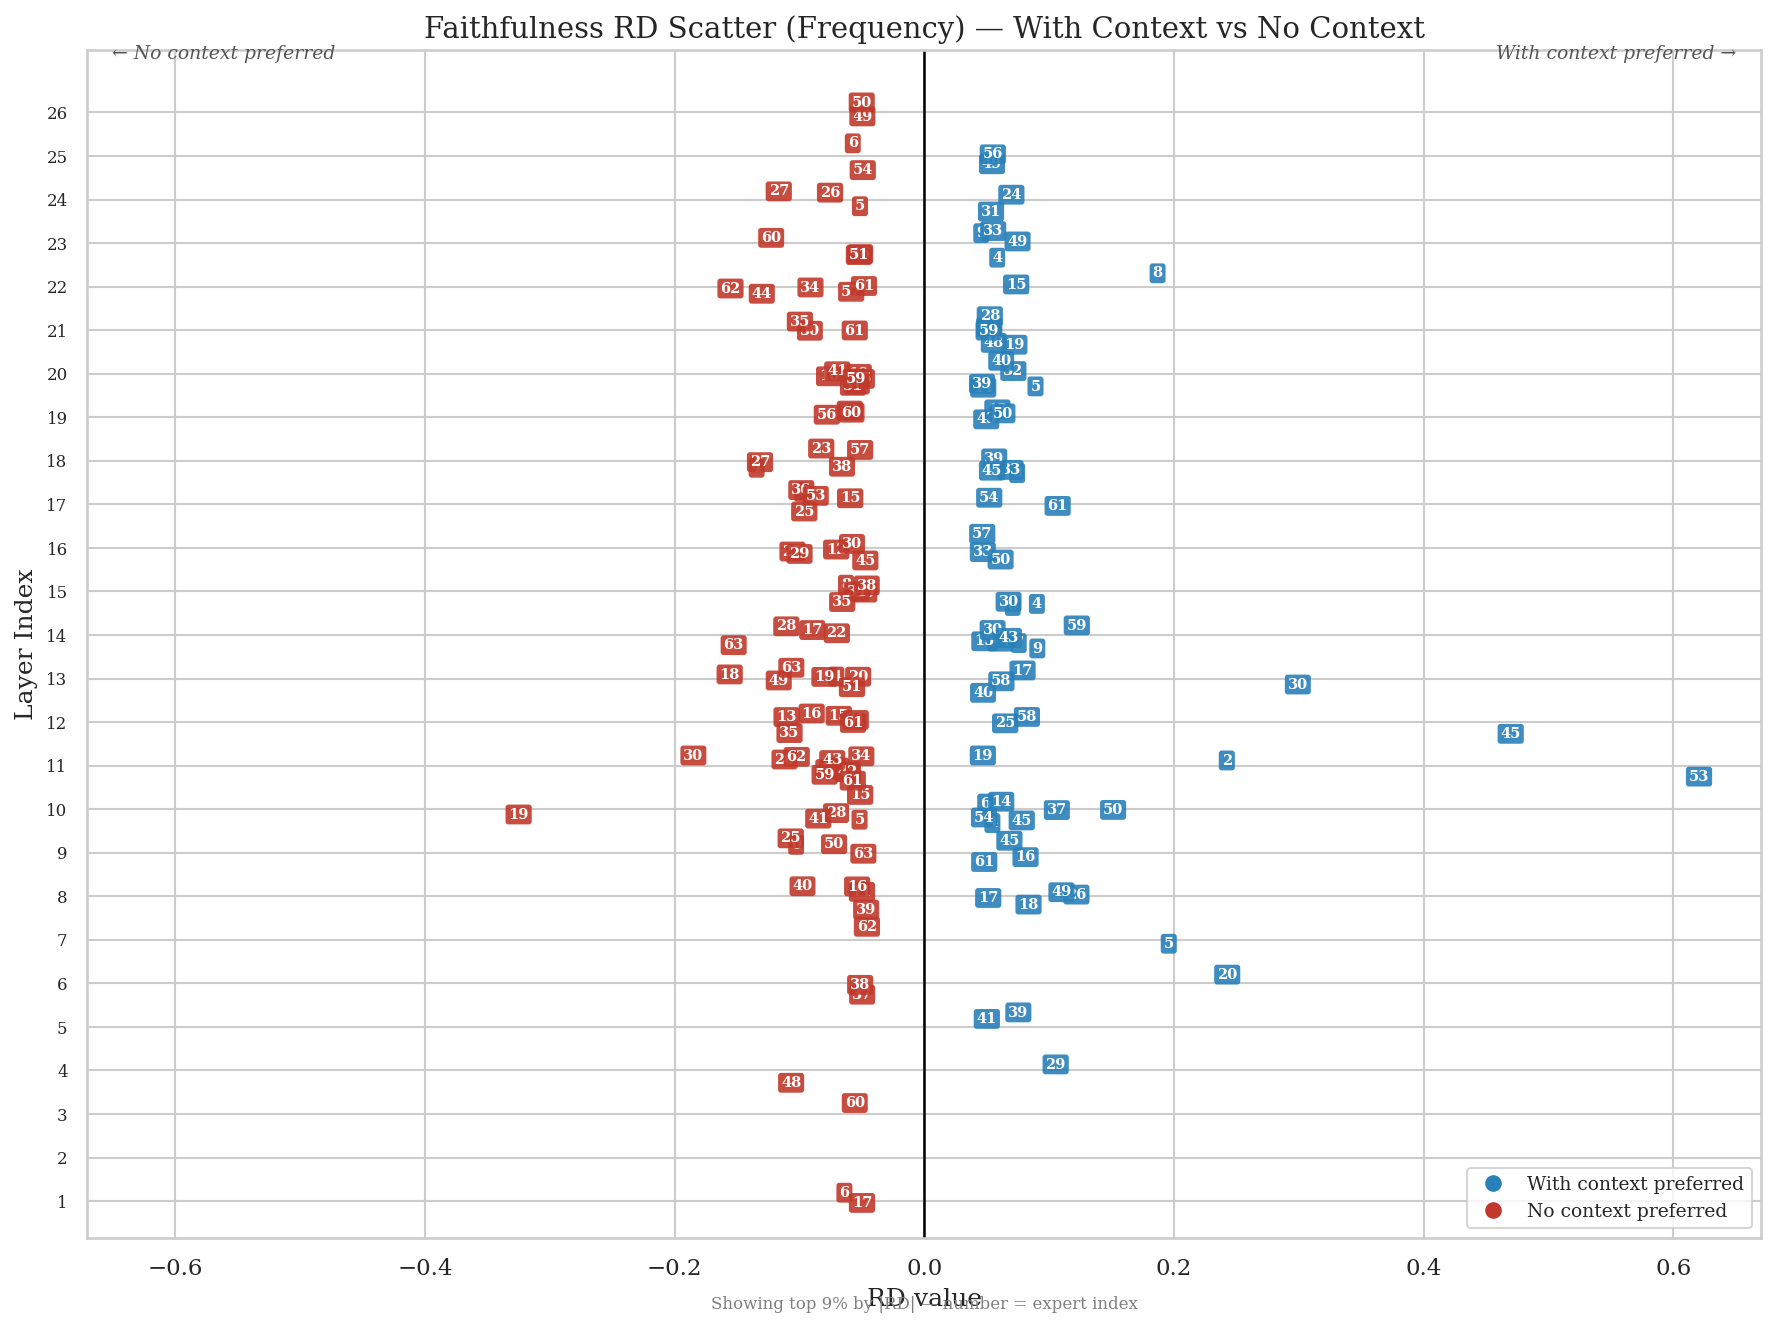

In [6]:
def plot_butterfly(rd_by_layer, layers_sorted, label_a, label_b, title,
                   threshold_quantile=0.90, color_a='#2980b9', color_b='#c0392b'):
    all_abs = np.concatenate([np.abs(rd) for rd in rd_by_layer.values()])
    threshold = np.quantile(all_abs, threshold_quantile)

    rng = np.random.default_rng(42)
    xs, ys, expert_labels, colors = [], [], [], []

    for layer in layers_sorted:
        layer_idx = int(layer.split('.')[2])
        rd = rd_by_layer[layer]
        for expert_idx in range(len(rd)):
            if abs(rd[expert_idx]) >= threshold:
                val = float(rd[expert_idx])
                xs.append(val)
                ys.append(layer_idx + rng.uniform(-0.35, 0.35))
                expert_labels.append(str(expert_idx))
                colors.append(color_a if val > 0 else color_b)

    abs_max = max(abs(v) for v in xs)
    x_pad = max(0.02, abs_max * 0.08)
    x_max = abs_max + x_pad
    layer_indices = [int(l.split('.')[2]) for l in layers_sorted]

    fig, ax = plt.subplots(figsize=(12, 9))
    for x, y, lbl, c in zip(xs, ys, expert_labels, colors):
        ax.text(x, y, lbl, ha='center', va='center',
                fontsize=7, color='white', fontweight='bold', zorder=3,
                bbox=dict(boxstyle='round,pad=0.2', facecolor=c, edgecolor='none', alpha=0.9))

    ax.axvline(0, color='black', linewidth=1.2, zorder=1)
    ax.set_xlim(-x_max, x_max)
    ax.set_ylim(min(ys) - 0.8, max(ys) + 1.2)
    ax.set_yticks(layer_indices)
    ax.set_yticklabels(layer_indices, fontsize=8)

    y_top = max(ys) + 0.9
    ax.text(-x_max * 0.97, y_top, f'← {label_b} preferred',
            ha='left', va='bottom', fontsize=9, color='#555555', style='italic')
    ax.text(x_max * 0.97, y_top, f'{label_a} preferred →',
            ha='right', va='bottom', fontsize=9, color='#555555', style='italic')

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=color_a, markersize=9, label=f'{label_a} preferred'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=color_b, markersize=9, label=f'{label_b} preferred'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
    ax.set_xlabel('RD value')
    ax.set_ylabel('Layer Index')
    ax.set_title(title)
    pct = int((1 - threshold_quantile) * 100)
    ax.text(0.5, -0.06, f'Showing top {pct}% by |RD| — number = expert index',
            transform=ax.transAxes, fontsize=8, ha='center', color='grey')
    plt.tight_layout()
    plt.show()

plot_butterfly(rd_freq, layers_sorted,
               label_a='With context', label_b='No context',
               title='Faithfulness RD Scatter (Frequency) — With Context vs No Context')

## 5. Butterfly Scatter — Significant RD Experts (Logit)

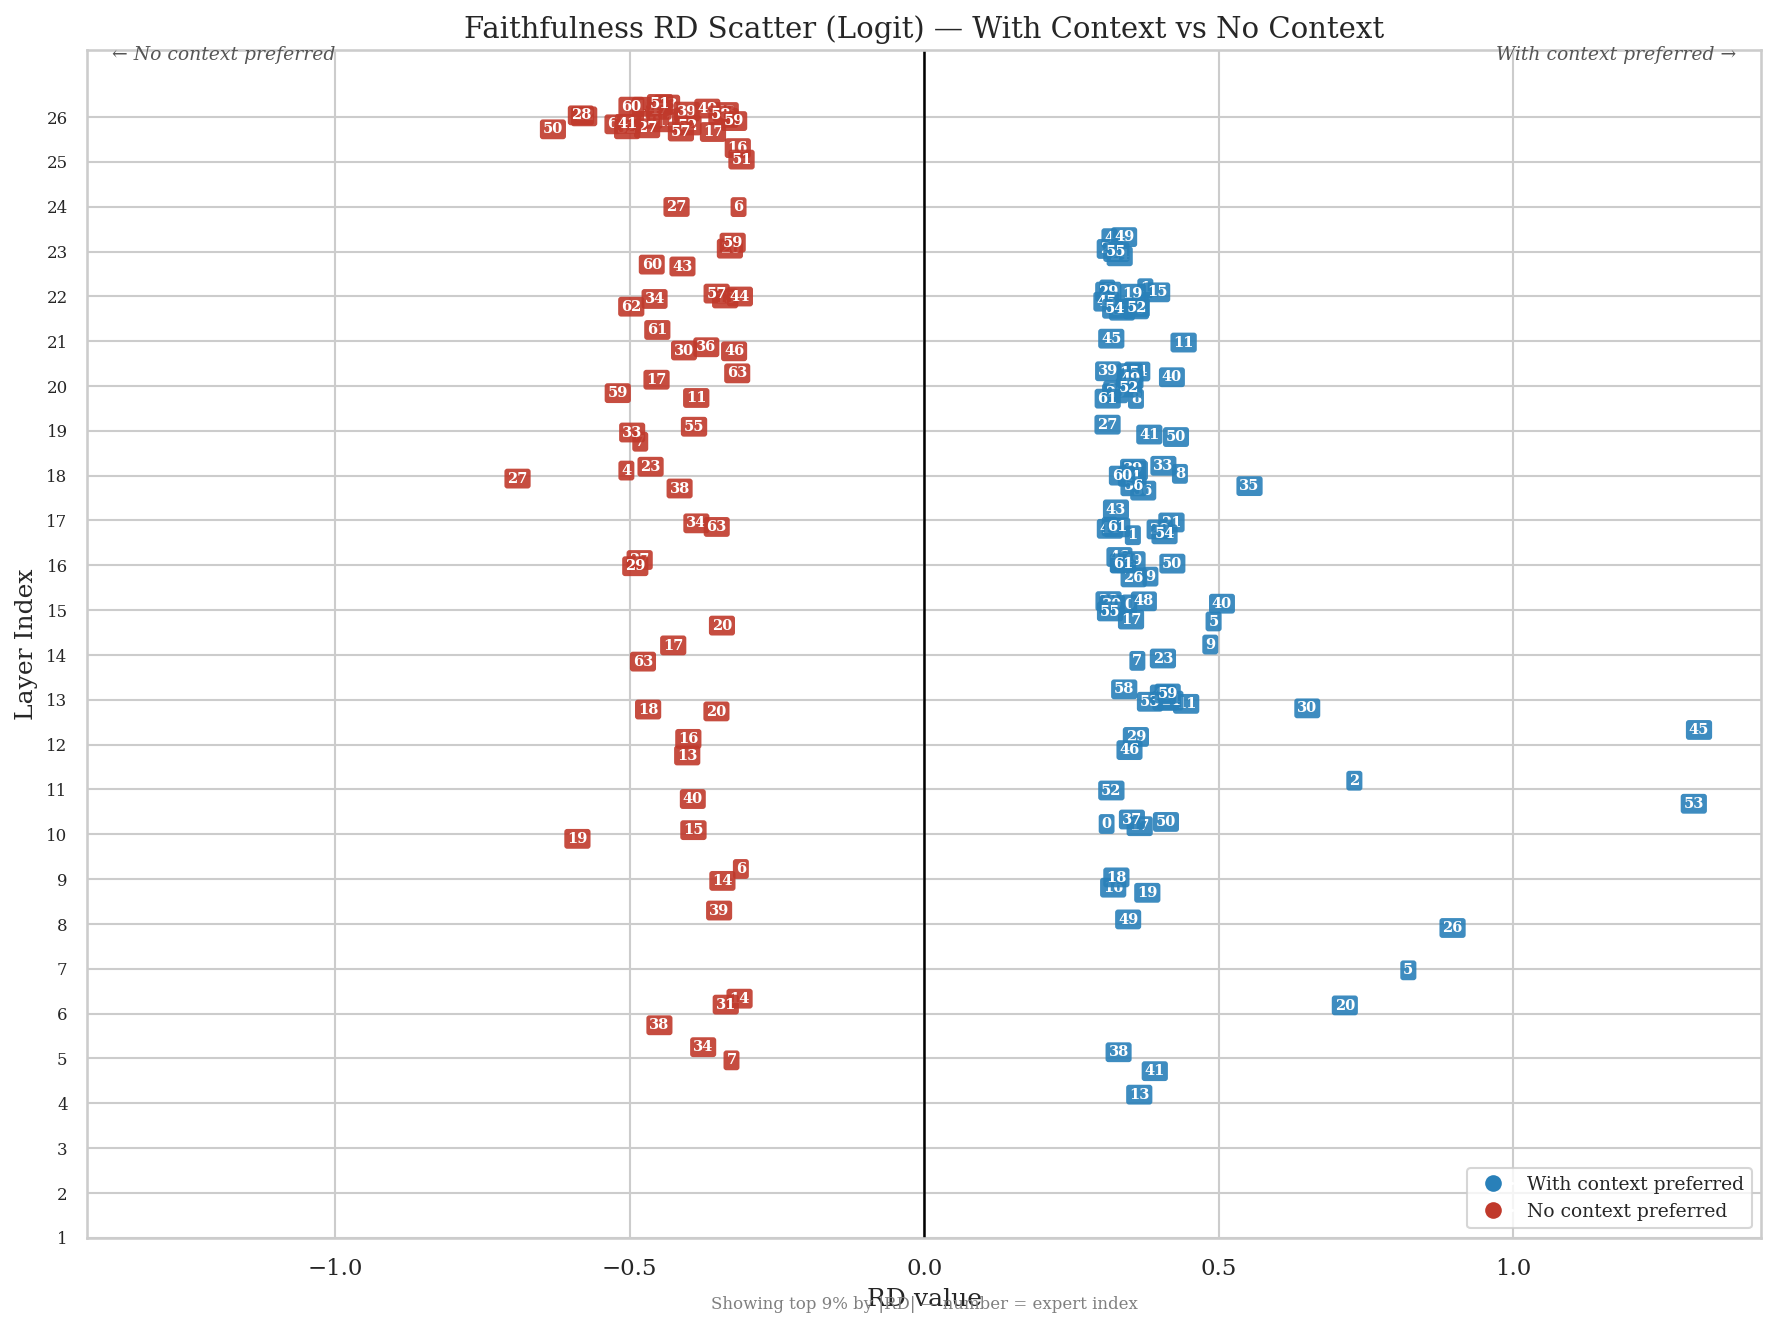

In [7]:
plot_butterfly(rd_logit, layers_sorted,
               label_a='With context', label_b='No context',
               title='Faithfulness RD Scatter (Logit) — With Context vs No Context')

## 6. Layer Distribution of Context-Preferred and No-Context-Preferred Experts

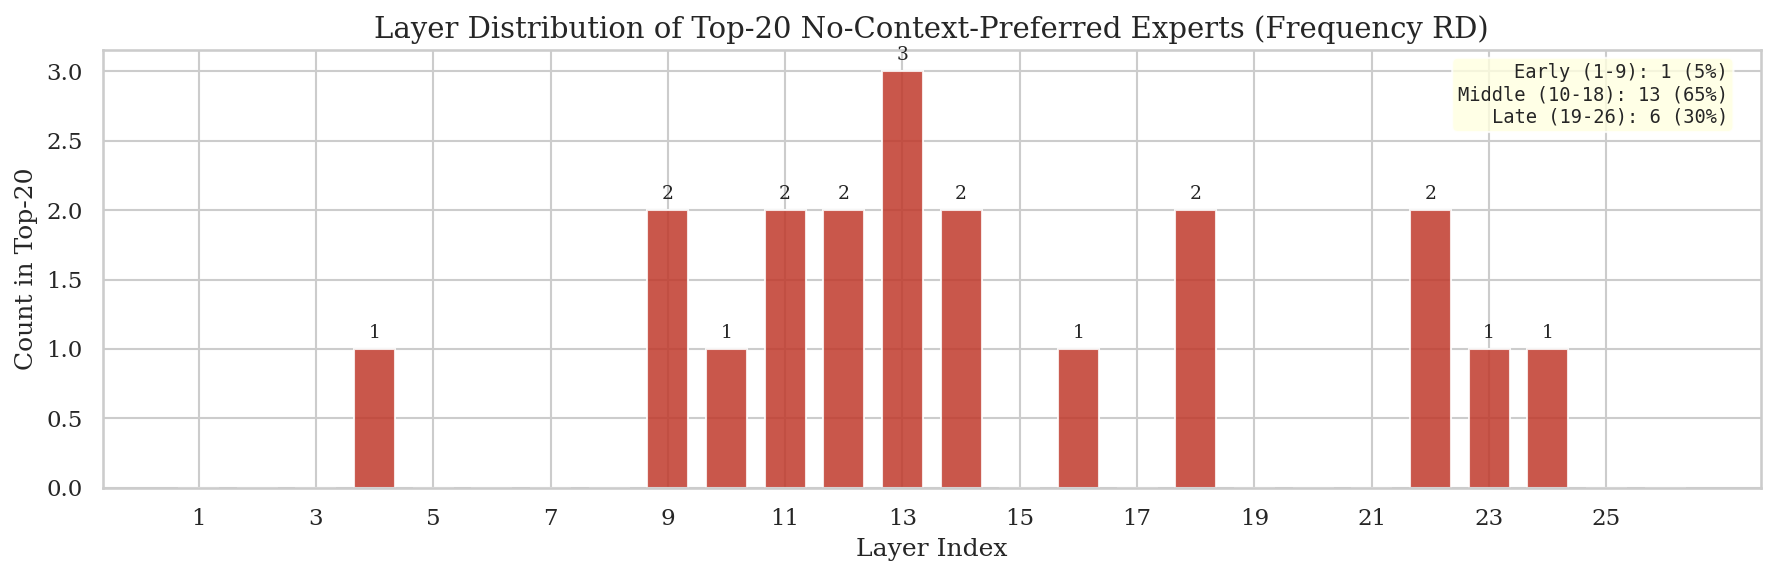

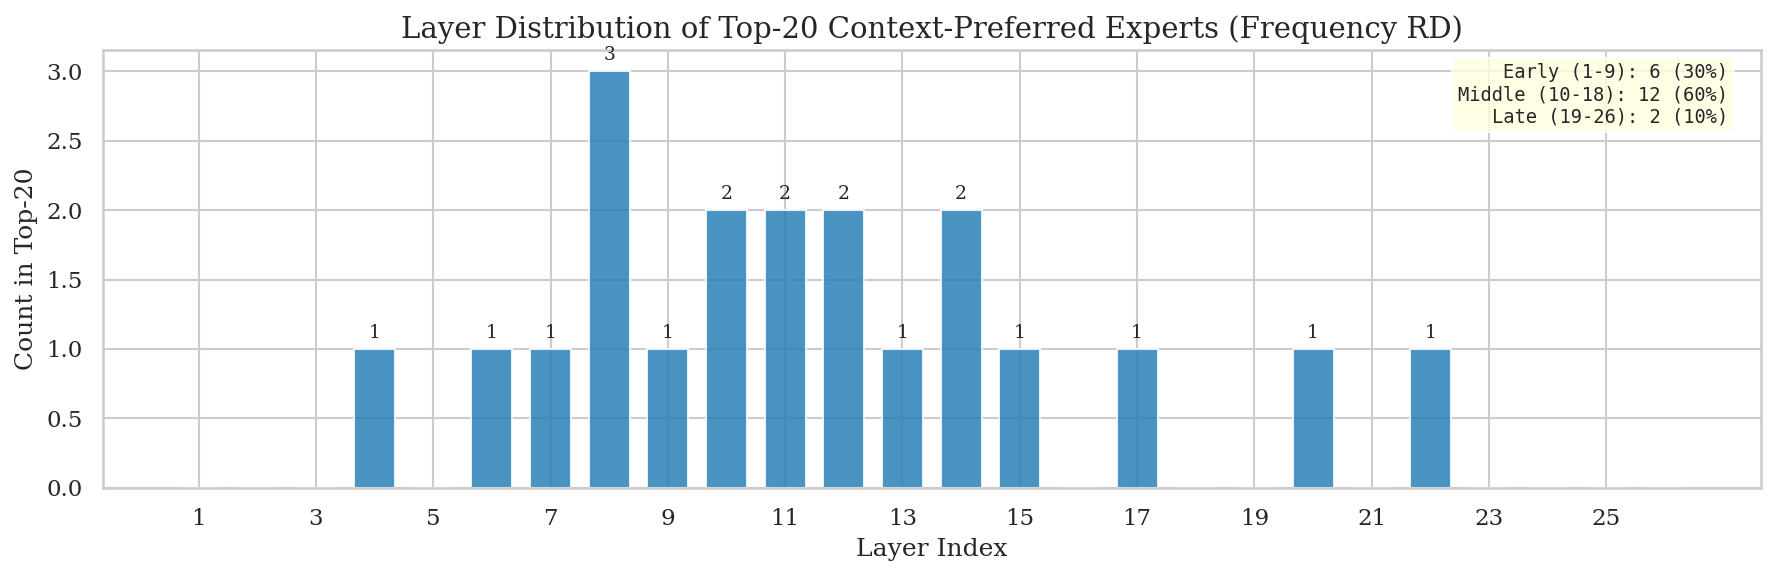

In [8]:
# Among the top-20 no-context-preferred (most negative RD) experts, which layers do they come from?
rows = []
for layer, rd in rd_freq.items():
    layer_idx = int(layer.split('.')[2])
    for expert_idx, val in enumerate(rd):
        rows.append((val, layer_idx, expert_idx))

rows.sort()  # ascending = most negative first
top_neg = rows[:20]

layer_counts = {}
for val, layer_idx, _ in top_neg:
    layer_counts[layer_idx] = layer_counts.get(layer_idx, 0) + 1

fig, ax = plt.subplots(figsize=(12, 4))
all_layer_idxs = [int(l.split('.')[2]) for l in layers_sorted]
counts = [layer_counts.get(li, 0) for li in all_layer_idxs]
bars = ax.bar(all_layer_idxs, counts, color='#c0392b', alpha=0.85, width=0.7)
ax.set_xlabel('Layer Index')
ax.set_ylabel('Count in Top-20')
ax.set_title('Layer Distribution of Top-20 No-Context-Preferred Experts (Frequency RD)')
ax.set_xticks(all_layer_idxs[::2])

for bar, count in zip(bars, counts):
    if count > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                str(count), ha='center', va='bottom', fontsize=9)

early = sum(c for li, c in layer_counts.items() if li <= 8)
middle = sum(c for li, c in layer_counts.items() if 9 <= li <= 17)
late = sum(c for li, c in layer_counts.items() if li >= 18)
total = early + middle + late

breakdown_text = f'Early (1-9): {early} ({early/total*100:.0f}%)\nMiddle (10-18): {middle} ({middle/total*100:.0f}%)\nLate (19-26): {late} ({late/total*100:.0f}%)'
ax.text(0.98, 0.97, breakdown_text, transform=ax.transAxes,
        fontsize=9, ha='right', va='top', family='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'faith_neg_expert_layers.png'), dpi=300, bbox_inches='tight')
plt.show()

# Also plot context-preferred experts (most positive RD)
rows_pos = []
for layer, rd in rd_freq.items():
    layer_idx = int(layer.split('.')[2])
    for expert_idx, val in enumerate(rd):
        rows_pos.append((val, layer_idx, expert_idx))

rows_pos.sort(reverse=True)  # descending = most positive first
top_pos = rows_pos[:20]

layer_counts_pos = {}
for val, layer_idx, _ in top_pos:
    layer_counts_pos[layer_idx] = layer_counts_pos.get(layer_idx, 0) + 1

fig, ax = plt.subplots(figsize=(12, 4))
counts_pos = [layer_counts_pos.get(li, 0) for li in all_layer_idxs]
bars_pos = ax.bar(all_layer_idxs, counts_pos, color='#2980b9', alpha=0.85, width=0.7)
ax.set_xlabel('Layer Index')
ax.set_ylabel('Count in Top-20')
ax.set_title('Layer Distribution of Top-20 Context-Preferred Experts (Frequency RD)')
ax.set_xticks(all_layer_idxs[::2])

for bar, count in zip(bars_pos, counts_pos):
    if count > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                str(count), ha='center', va='bottom', fontsize=9)

early_pos = sum(c for li, c in layer_counts_pos.items() if li <= 8)
middle_pos = sum(c for li, c in layer_counts_pos.items() if 9 <= li <= 17)
late_pos = sum(c for li, c in layer_counts_pos.items() if li >= 18)
total_pos = early_pos + middle_pos + late_pos

breakdown_text_pos = f'Early (1-9): {early_pos} ({early_pos/total_pos*100:.0f}%)\nMiddle (10-18): {middle_pos} ({middle_pos/total_pos*100:.0f}%)\nLate (19-26): {late_pos} ({late_pos/total_pos*100:.0f}%)'
ax.text(0.98, 0.97, breakdown_text_pos, transform=ax.transAxes,
        fontsize=9, ha='right', va='top', family='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'faith_pos_expert_layers.png'), dpi=300, bbox_inches='tight')
plt.show()